In [1]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

In [2]:
df = pd.read_csv("winequality-red.csv", sep = ";")

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [5]:
media = df.mean()
desvio = df.std()

In [6]:
df_estandar = (df - media) / desvio
df_estandar.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.528194,0.961576,-1.391037,-0.453077,-0.243630,-0.466047,-0.379014,0.558100,1.288240,-0.579025,-0.959946,-0.787576
1,-0.298454,1.966827,-1.391037,0.043403,0.223805,0.872365,0.624168,0.028252,-0.719708,0.128910,-0.584594,-0.787576


In [7]:
df_estandar.mean().round()

fixed acidity           0.0
volatile acidity        0.0
citric acid            -0.0
residual sugar         -0.0
chlorides               0.0
free sulfur dioxide    -0.0
total sulfur dioxide    0.0
density                -0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

In [8]:
df_estandar.std().round(2)

fixed acidity           1.0
volatile acidity        1.0
citric acid             1.0
residual sugar          1.0
chlorides               1.0
free sulfur dioxide     1.0
total sulfur dioxide    1.0
density                 1.0
pH                      1.0
sulphates               1.0
alcohol                 1.0
quality                 1.0
dtype: float64

In [9]:
pca = PCA(n_components = 12)
X_pca = pca.fit_transform(df_estandar)

In [10]:
X_pca

array([[-1.77888507, -1.15694121, -1.38614692, ...,  0.07308931,
        -0.26285437,  0.04834668],
       [-1.00387062, -2.07118989,  0.00775634, ..., -0.56555891,
         0.04876832, -0.13952151],
       [-0.91549679, -1.39299841, -0.69906772, ..., -0.16201401,
        -0.19907819, -0.12035334],
       ...,
       [-1.36583781,  0.51739913,  1.25030522, ..., -0.75261825,
         0.2351928 , -0.40216588],
       [-2.36640641, -0.70332476,  0.89920089, ..., -0.72322703,
         0.73702254,  0.036176  ],
       [-0.28868597,  1.24045778,  1.21771422, ...,  0.30578156,
         0.77700268, -0.44902679]])

In [11]:
X_pca_tabla = pd.DataFrame(
    X_pca,
    columns = [f"PC{i}" for i in range(1,13)]
)
X_pca_tabla.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,-1.778885,-1.156941,-1.386147,-0.044930,0.233811,0.976677,0.110493,-0.040307,0.294328,0.073089,-0.262854,0.048347
1,-1.003871,-2.071190,0.007756,0.465974,0.182397,-0.657569,1.376359,0.176659,-0.587158,-0.565559,0.048768,-0.139522
2,-0.915497,-1.392998,-0.699068,0.345184,0.095180,-0.254743,0.720113,0.088659,-0.546324,-0.162014,-0.199078,-0.120353
3,2.403325,0.213725,0.066360,-0.888904,-1.524265,0.132176,-0.200597,0.202752,0.506053,0.241059,-0.107582,0.319664
4,-1.778885,-1.156941,-1.386147,-0.044930,0.233811,0.976677,0.110493,-0.040307,0.294328,0.073089,-0.262854,0.048347


In [12]:
pca.explained_variance_ratio_

array([0.26009731, 0.1868235 , 0.14024331, 0.10125174, 0.0811053 ,
       0.05521602, 0.05152648, 0.04215605, 0.03427563, 0.02732662,
       0.01501822, 0.00495983])

In [13]:
pca.explained_variance_ratio_.cumsum()

array([0.26009731, 0.44692081, 0.58716412, 0.68841586, 0.76952116,
       0.82473718, 0.87626366, 0.91841971, 0.95269534, 0.98002195,
       0.99504017, 1.        ])

In [14]:
data_clean = X_pca_tabla.loc[:, "PC1" : "PC5"]

In [15]:
data_clean.head()

,PC1,PC2,PC3,PC4,PC5
0,-1.778885,-1.156941,-1.386147,-0.044930,0.233811
1,-1.003871,-2.071190,0.007756,0.465974,0.182397
2,-0.915497,-1.392998,-0.699068,0.345184,0.095180
3,2.403325,0.213725,0.066360,-0.888904,-1.524265
4,-1.778885,-1.156941,-1.386147,-0.044930,0.233811


In [16]:
from sklearn.cluster import KMeans

In [17]:
modelo = KMeans(
    n_clusters = 5,
    n_init = 10,
    max_iter = 300
)
modelo.fit(data_clean)

KMeans(n_clusters=5, n_init=10)

In [18]:
acum = []
for i in range(1,11):
    modelo = KMeans(
        n_clusters = i,
        n_init = 10,
        max_iter = 300
    )
    modelo.fit(data_clean)
    acum.append([i, modelo.inertia_])

<Axes: >

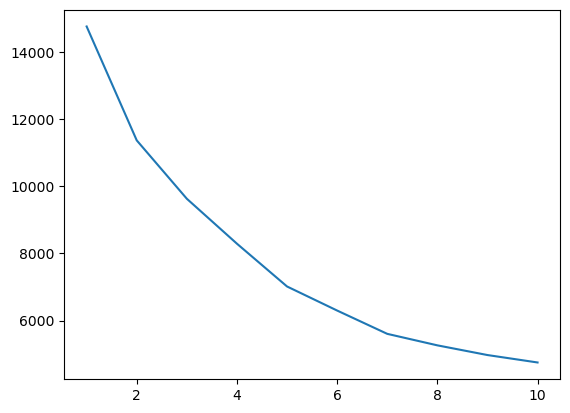

In [19]:
sns.lineplot(x = np.array(acum)[:,0], y = np.array(acum)[:, 1])

In [20]:
modelo = KMeans(
    n_clusters = 5,
    n_init = 10,
    max_iter = 300
)
modelo.fit(data_clean)

KMeans(n_clusters=5, n_init=10)

In [21]:
X_pca_tabla.shape

(1599, 12)

In [22]:
df.shape

(1599, 12)

In [23]:
data_clean.shape

(1599, 5)

In [24]:
df["cluster"] = modelo.labels_

In [25]:
df.groupby("cluster").mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
cluster,,,,,,,,,,,,
0,10.692938,0.402105,0.494322,2.825847,0.086907,10.206215,28.966102,0.998263,3.179379,0.718051,10.644256,5.997175
1,7.509437,0.651080,0.120708,2.216606,0.084152,11.416515,34.205082,0.996597,3.371361,0.585826,9.960768,5.237750
2,8.462069,0.531034,0.493793,1.975862,0.351172,15.137931,62.068966,0.997097,3.050690,1.288621,9.482759,5.344828
3,8.215224,0.537866,0.292209,3.119104,0.088448,27.507463,90.411940,0.997477,3.289731,0.629582,9.774129,5.268657
4,7.220000,0.446394,0.241152,2.229242,0.069430,17.656061,39.736364,0.994597,3.396424,0.688242,11.698687,6.312121
